In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(7)
tf.random.set_seed(7)


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train = y_train.squeeze()
y_test  = y_test.squeeze()

# CIFAR-10 labels: cat=3, dog=5
CAT, DOG = 3, 5

rng = np.random.RandomState(7)

train_cat_all = np.where(y_train == CAT)[0]
train_dog_all = np.where(y_train == DOG)[0]

val_cat_all = np.where(y_test == CAT)[0]
val_dog_all = np.where(y_test == DOG)[0]

# Pick 200 cats + 200 dogs for training
train_cat_idx = rng.choice(train_cat_all, size=200, replace=False)
train_dog_idx = rng.choice(train_dog_all, size=200, replace=False)
train_idx = np.concatenate([train_cat_idx, train_dog_idx])

# Pick 50 cats + 50 dogs for validation (100 total)
val_cat_idx = rng.choice(val_cat_all, size=50, replace=False)
val_dog_idx = rng.choice(val_dog_all, size=50, replace=False)
val_idx = np.concatenate([val_cat_idx, val_dog_idx])

# Build sets
Xtr = x_train[train_idx].astype("float32") / 255.0
Ytr = (y_train[train_idx] == DOG).astype("float32")  # dog=1, cat=0

Xva = x_test[val_idx].astype("float32") / 255.0
Yva = (y_test[val_idx] == DOG).astype("float32")

# Shuffle training set
perm = rng.permutation(len(Xtr))
Xtr, Ytr = Xtr[perm], Ytr[perm]

print("Train:", Xtr.shape, Ytr.shape, "| Val:", Xva.shape, Yva.shape)
print("Train cats:", int((Ytr==0).sum()), "dogs:", int((Ytr==1).sum()))


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 108s 1us/step
Train: (400, 32, 32, 3) (400,) | Val: (100, 32, 32, 3) (100,)
Train cats: 200 dogs: 200


In [3]:
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="augment")


In [4]:
inputs = tf.keras.layers.Input(shape=(32,32,3))
x = augment(inputs)  # augmentation only helps during training automatically

x = tf.keras.layers.Conv2D(16, 3, padding="same")(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPool2D()(x)

x = tf.keras.layers.Conv2D(32, 3, padding="same")(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPool2D()(x)

x = tf.keras.layers.Conv2D(64, 3, padding="same")(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPool2D()(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(64, activation="relu")(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,249 (348.63 KB)

 Trainable params: 89,249 (348.63 KB)

 Non-trainable params: 0 (0.00 B)

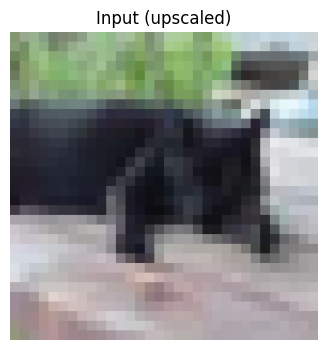

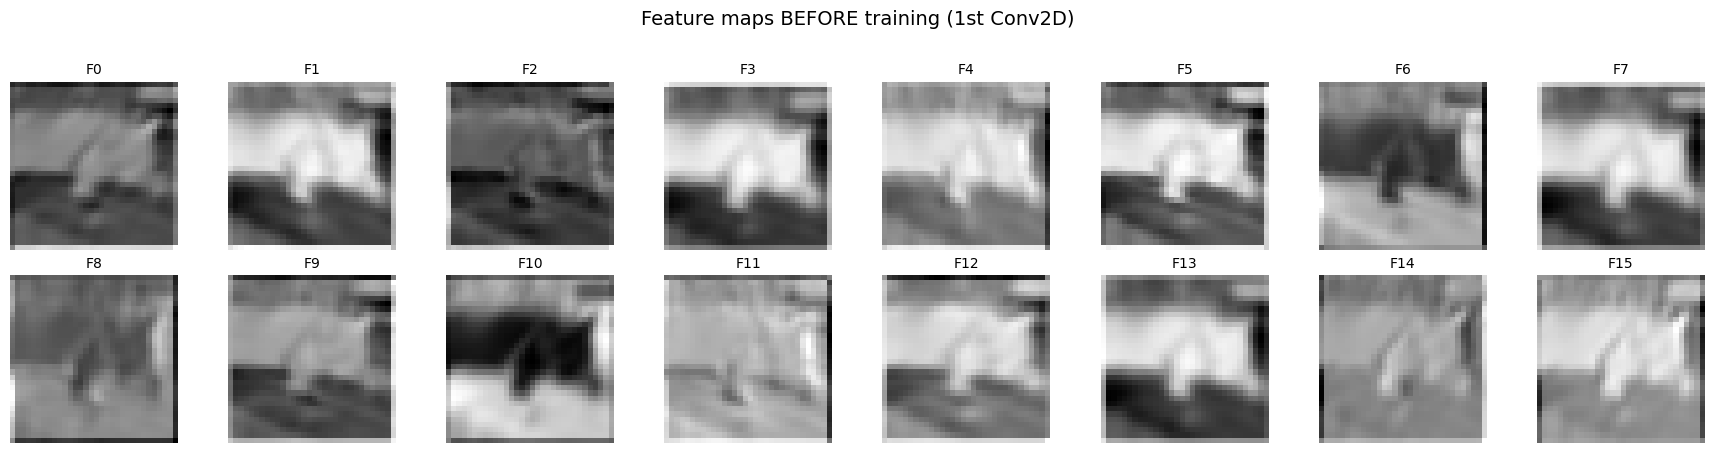

In [5]:
def norm01(m):
    m = m - np.min(m)
    m = m / (np.max(m) + 1e-8)
    return m

# pick one validation image
sample = Xva[0:1]

# feature model: output of the FIRST Conv2D layer
first_conv_layer = None
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        first_conv_layer = layer
        break

feat_model = tf.keras.Model(inputs=model.input, outputs=first_conv_layer.output)

before_maps = feat_model(sample).numpy()[0]  # (32,32,C)

# show input bigger so it's clear
plt.figure(figsize=(4,4))
plt.imshow(tf.image.resize(sample[0], (256,256), method="nearest"))
plt.title("Input (upscaled)")
plt.axis("off")
plt.show()

C = before_maps.shape[-1]
cols = 8
rows = int(np.ceil(C/cols))
plt.figure(figsize=(2.2*cols, 2.2*rows))
for i in range(C):
    plt.subplot(rows, cols, i+1)
    plt.imshow(norm01(before_maps[:,:,i]), cmap="gray", interpolation="nearest")
    plt.title(f"F{i}", fontsize=10)
    plt.axis("off")
plt.suptitle("Feature maps BEFORE training (1st Conv2D)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


In [6]:
history = model.fit(
    Xtr, Ytr,
    validation_data=(Xva, Yva),
    epochs=15,
    batch_size=32,
    verbose=1
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.4775 - loss: 0.7031 - val_accuracy: 0.5100 - val_loss: 0.6916
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4875 - loss: 0.6913 - val_accuracy: 0.5300 - val_loss: 0.6912
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5000 - loss: 0.6923 - val_accuracy: 0.5500 - val_loss: 0.6892
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5300 - loss: 0.6885 - val_accuracy: 0.5100 - val_loss: 0.6845
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5575 - loss: 0.6875 - val_accuracy: 0.5300 - val_loss: 0.6871
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5325 - loss: 0.6844 - val_accuracy: 0.5800 - val_loss: 0.6802
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5625 - loss: 0.6740 - val_accuracy: 0.5500 - val_loss: 0.6790
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5825 - loss: 0.6723 - val_accuracy: 0.5200 - v

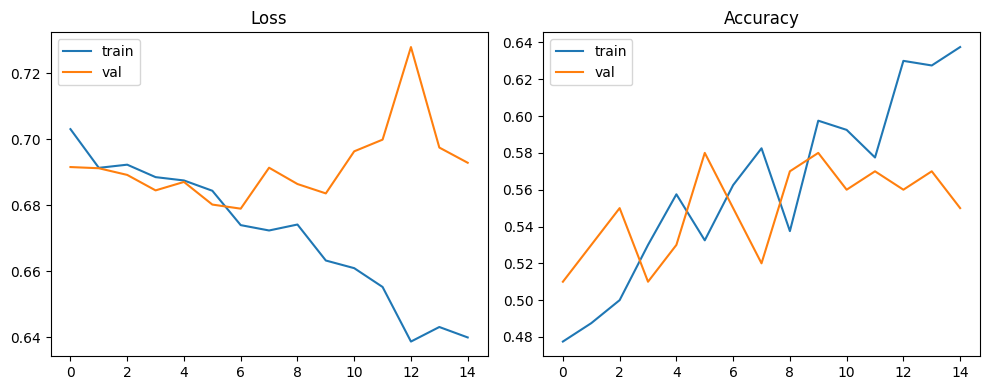

In [8]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


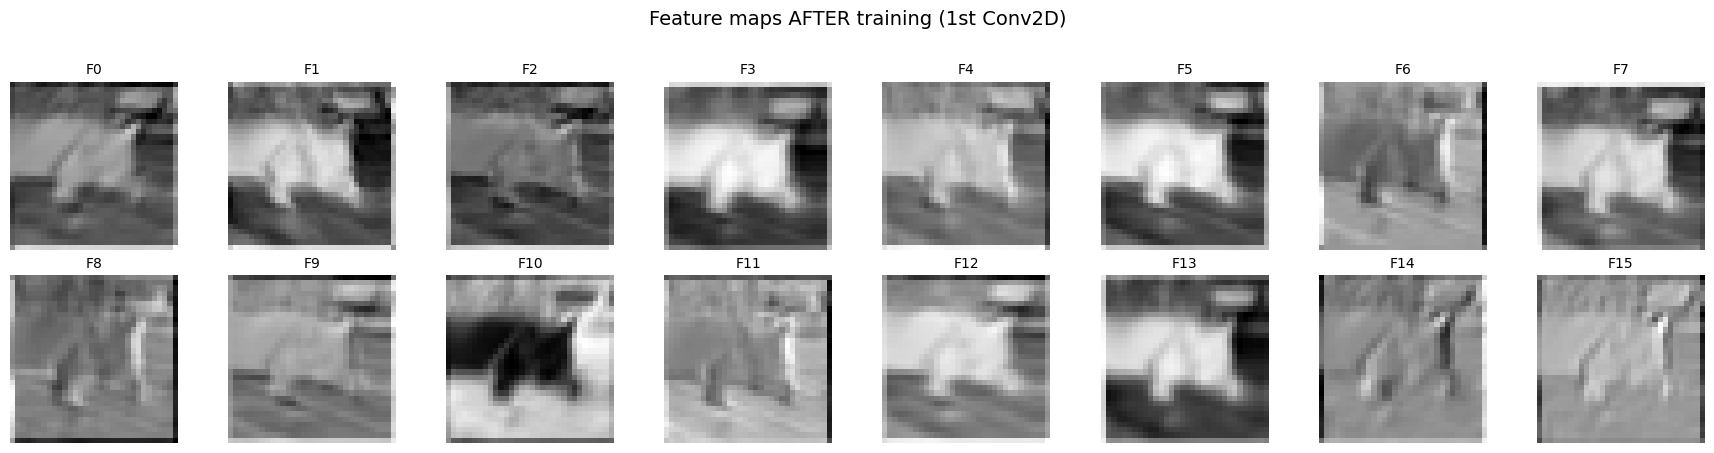

In [9]:
after_maps = feat_model(sample).numpy()[0]

C = after_maps.shape[-1]
cols = 8
rows = int(np.ceil(C/cols))
plt.figure(figsize=(2.2*cols, 2.2*rows))
for i in range(C):
    plt.subplot(rows, cols, i+1)
    plt.imshow(norm01(after_maps[:,:,i]), cmap="gray", interpolation="nearest")
    plt.title(f"F{i}", fontsize=10)
    plt.axis("off")
plt.suptitle("Feature maps AFTER training (1st Conv2D)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


In [10]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(7)
tf.random.set_seed(7)

# ---- CHANGE THESE ----
TRAIN_PER_CLASS = 5000   # e.g., 2000, 5000, 7000
VAL_PER_CLASS   = 1000   # e.g., 200, 500, 1000
BATCH_SIZE      = 64
EPOCHS          = 25


In [11]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train = y_train.squeeze()
y_test  = y_test.squeeze()

CAT, DOG = 3, 5
rng = np.random.RandomState(7)

train_cat_all = np.where(y_train == CAT)[0]
train_dog_all = np.where(y_train == DOG)[0]
val_cat_all   = np.where(y_test  == CAT)[0]
val_dog_all   = np.where(y_test  == DOG)[0]

train_cat_idx = rng.choice(train_cat_all, size=TRAIN_PER_CLASS, replace=False)
train_dog_idx = rng.choice(train_dog_all, size=TRAIN_PER_CLASS, replace=False)
train_idx = np.concatenate([train_cat_idx, train_dog_idx])

val_cat_idx = rng.choice(val_cat_all, size=VAL_PER_CLASS, replace=False)
val_dog_idx = rng.choice(val_dog_all, size=VAL_PER_CLASS, replace=False)
val_idx = np.concatenate([val_cat_idx, val_dog_idx])

Xtr = x_train[train_idx].astype("float32") / 255.0
Ytr = (y_train[train_idx] == DOG).astype("float32")  # dog=1, cat=0
Xva = x_test[val_idx].astype("float32") / 255.0
Yva = (y_test[val_idx] == DOG).astype("float32")

perm = rng.permutation(len(Xtr))
Xtr, Ytr = Xtr[perm], Ytr[perm]

print("Train:", Xtr.shape, " Val:", Xva.shape)
print("Train cats:", int((Ytr==0).sum()), "dogs:", int((Ytr==1).sum()))


Train: (10000, 32, 32, 3)  Val: (2000, 32, 32, 3)
Train cats: 5000 dogs: 5000


In [12]:
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="augment")

train_ds = tf.data.Dataset.from_tensor_slices((Xtr, Ytr)).shuffle(4096).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((Xva, Yva)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [13]:
inputs = tf.keras.layers.Input(shape=(32,32,3))
x = augment(inputs)

def conv_block(x, filters):
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPool2D()(x)
    return x

x = conv_block(x, 32)
x = conv_block(x, 64)
x = conv_block(x, 128)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(64, activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,241 (399.38 KB)

 Trainable params: 101,793 (397.63 KB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
]


In [15]:
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=1)

Epoch 1/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 116ms/step - accuracy: 0.5711 - loss: 0.6829 - val_accuracy: 0.5040 - val_loss: 0.6905 - learning_rate: 0.0010
Epoch 2/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - accuracy: 0.6187 - loss: 0.6524 - val_accuracy: 0.5665 - val_loss: 0.6692 - learning_rate: 0.0010
Epoch 3/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.6501 - loss: 0.6248 - val_accuracy: 0.6080 - val_loss: 0.6924 - learning_rate: 0.0010
Epoch 4/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 113ms/step - accuracy: 0.6815 - loss: 0.6027 - val_accuracy: 0.6740 - val_loss: 0.5933 - learning_rate: 0.0010
Epoch 5/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 118ms/step - accuracy: 0.6950 - loss: 0.5775 - val_accuracy: 0.7195 - val_loss: 0.5840 - learning_rate: 0.0010
Epoch 6/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - accuracy: 0.7055 - loss: 0.5610 - val_accuracy: 0.6085 - val_loss: 0.7064 - learning_rate: 0.0010
Epoch 7/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 115ms/step - accuracy: 0.7

/tmp/ipykernel_7019/3357572931.py:24: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


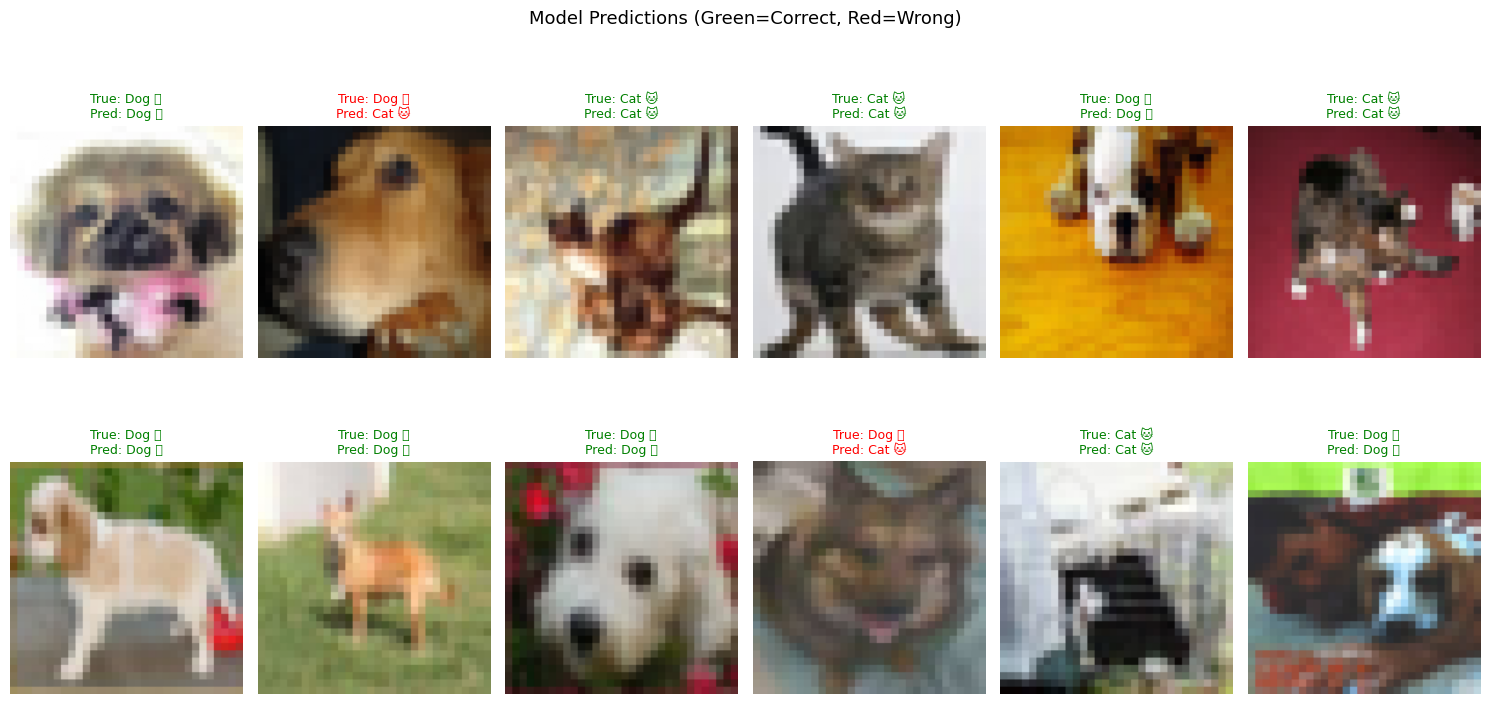

In [16]:
import numpy as np
import matplotlib.pyplot as plt

N = 12
idx = np.random.choice(len(Xva), size=N, replace=False)
x_batch = Xva[idx]
probs = model.predict(x_batch, verbose=0).squeeze()
preds = (probs > 0.5).astype(int)
true  = Yva[idx].astype(int)

def name(v):
    return "Dog 🐶" if v == 1 else "Cat 🐱"

plt.figure(figsize=(15, 8))
for i in range(N):
    plt.subplot(2, 6, i+1)
    plt.imshow(tf.image.resize(x_batch[i], (128,128), method="nearest"))
    t = name(true[i])
    p = name(preds[i])
    color = "green" if true[i] == preds[i] else "red"
    plt.title(f"True: {t}\nPred: {p}", fontsize=9, color=color)
    plt.axis("off")
plt.suptitle("Model Predictions (Green=Correct, Red=Wrong)", fontsize=13)
plt.tight_layout()
plt.show()